## 1. Import thư viện

In [55]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from de_core import *
import pandas as pd

## 2. Đọc và hiển thị ảnh gốc

Đọc ảnh thành công
Chiều cao: 900
Chiều rộng 1600
Image shape: (900, 1600)


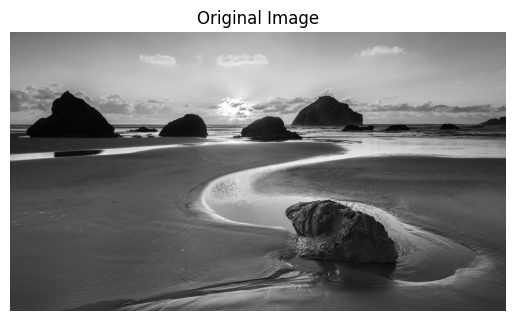

In [56]:
# Đọc ảnh xám
image = cv2.imread("test1.png", cv2.IMREAD_GRAYSCALE)

# Kiểm tra ảnh có đọc được không
if image is None:
    print("Không đọc được ảnh")
else:
    print("Đọc ảnh thành công")

# Hiển thị kích thước hình ảnh
height, width = image.shape
print("Chiều cao:", height)
print("Chiều rộng", width)

plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis("off")

print("Image shape:", image.shape)

## 3. Chia ảnh thành cặp pixel

In [57]:
pixel_pairs = []
for i in range(height):
    for j in range(0, width-1, 2): #bước nhảy 2 pixel
        x = int(image[i, j])
        y = int(image[i, j+1])
        pixel_pairs.append((x, y))

print("Số cặp pixel:", len(pixel_pairs))
print("10 cặp pixel đầu:")
print(pixel_pairs[:10])

Số cặp pixel: 720000
10 cặp pixel đầu:
[(105, 105), (105, 105), (105, 105), (106, 106), (107, 107), (107, 108), (108, 107), (107, 106), (109, 108), (107, 107)]


## 4. Nhúng dữ liệu

In [58]:
# Chuỗi dữ liệu bí mật (ví dụ)
secret_data = "101101001011"

bit_index = 0

stego_image = image.copy()

for i in range(height):
    for j in range(0, width-1, 2):

        if bit_index >= len(secret_data):
            break

        x = int(stego_image[i, j])
        y = int(stego_image[i, j+1])

        # Bước 3: tính difference và average
        d = x - y
        m = (x + y) // 2

        # Bit cần nhúng
        b = int(secret_data[bit_index])

        # Difference Expansion
        d_new = 2 * d + b

        # Pixel mới
        x_new = m + (d_new + 1) // 2
        y_new = m - d_new // 2

        # Kiểm tra overflow
        if 0 <= x_new <= 255 and 0 <= y_new <= 255:
            stego_image[i, j] = x_new
            stego_image[i, j+1] = y_new
            bit_index += 1
            
# Kiểm tra số bit đã nhúng
print("Số bit đã nhúng:", bit_index)

Số bit đã nhúng: 12


## 5. Tạo ảnh Stego Image

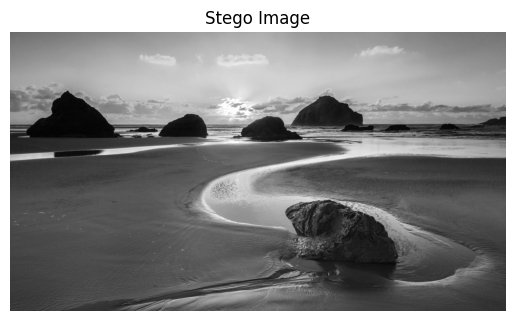

True

In [59]:
plt.imshow(stego_image, cmap='gray')
plt.title("Stego Image")
plt.axis("off")
plt.show()
# Lưu ảnh stego
cv2.imwrite("stego.png", stego_image)

## 6. Hàm trích xuất 

In [60]:

def extract_data(stego_image, payload_size):
    
    height, width = stego_image.shape

    extracted_bits = []

    recovered_image = stego_image.copy()

    for i in range(height):
        for j in range(0, width-1, 2):

            # Dừng khi extract đủ dữ liệu
            if len(extracted_bits) >= payload_size:
                break

            x = int(stego_image[i, j])
            y = int(stego_image[i, j+1])

            # difference stego
            d_new = x - y

            # extract bit
            b = d_new % 2
            extracted_bits.append(str(b))

            # recover difference
            d = d_new // 2

            # average
            m = (x + y) // 2

            # recover pixel
            x_re = m + (d + 1) // 2
            y_re = m - (d // 2)

            recovered_image[i, j] = x_re
            recovered_image[i, j+1] = y_re

        # thoát luôn vòng i nếu đủ payload
        if len(extracted_bits) >= payload_size:
            break

    extracted_data = ''.join(extracted_bits)

    return extracted_data, recovered_image

# Gọi hàm trích xuất
payload_size = len(secret_data)
extracted_data, recovered_image = extract_data(stego_image, payload_size)

# Kiểm tra dữ liệu trích xuất
print("Extracted bits:")
print(extracted_data[:50])

Extracted bits:
101101001011


## 7. Hàm phục hồi

Khôi phục thành công: True


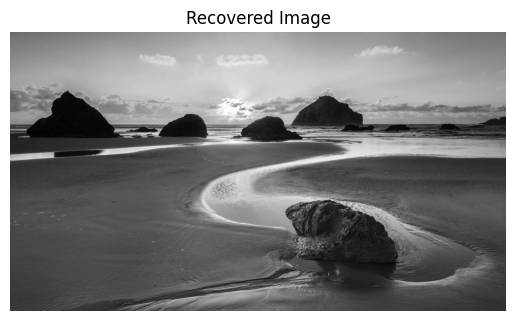

In [61]:
def recover_image(stego_image, payload_size):
    
    height, width = stego_image.shape

    recovered_image = stego_image.copy()
    extracted_bits = []

    for i in range(height):
        for j in range(0, width-1, 2):

            if len(extracted_bits) >= payload_size:
                break

            x_prime = int(stego_image[i, j])
            y_prime = int(stego_image[i, j+1])

            d_prime = x_prime - y_prime

            # extract bit
            b = d_prime % 2
            extracted_bits.append(str(b))

            # recover difference
            d = d_prime // 2

            m = (x_prime + y_prime) // 2

            x = m + (d + 1) // 2
            y = m - d // 2

            recovered_image[i, j] = x
            recovered_image[i, j+1] = y

        if len(extracted_bits) >= payload_size:
            break

    extracted_data = ''.join(extracted_bits)

    return recovered_image, extracted_data

# Gọi hàm phục hồi
payload_size = len(secret_data)
recovered_image, extracted_data = recover_image(stego_image, payload_size)

# Kiểm tra ảnh gốc có được phục hồi không
print("Khôi phục thành công:",
      np.array_equal(image, recovered_image))

# Hiển thị ảnh đã được phục hồi
plt.imshow(recovered_image, cmap='gray')
plt.title("Recovered Image")
plt.axis("off")
plt.show()

## 8. Hàm tính chỉ số

In [62]:
def compute_psnr(original, stego):
    mse = np.mean((original.astype(float) - stego.astype(float)) ** 2)
    if mse == 0:
        return float("inf")
    return 10 * np.log10((255 ** 2) / mse)

def compute_ssim(original, stego):
    value, _ = ssim(original, stego, full=True)
    return value

def compute_payload_bpp(used_bits, image_shape):
    total_pixels = image_shape[0] * image_shape[1]
    bpp = used_bits / total_pixels
    return used_bits, bpp

## 9. Tính toàn bộ thông số

In [63]:
def evaluate_rdh(image, stego_image, recovered_image, used_bits):
    
    payload, bpp = compute_payload_bpp(used_bits, image.shape)

    psnr_value = compute_psnr(image, stego_image)

    ssim_value = compute_ssim(image, stego_image)

    reversible = np.array_equal(image, recovered_image)

    results = pd.DataFrame({
        "Metric": [
            "Payload (bits)",
            "Embedding Capacity (bpp)",
            "PSNR (dB)",
            "SSIM",
            "Perfect Reversibility"
        ],
        "Value": [
            payload,
            round(bpp, 6),
            round(psnr_value, 4),
            round(ssim_value, 6),
            reversible
        ]
    })

    return results

# Gọi hàm đánh giá
used_bits = len(secret_data)
results = evaluate_rdh(image, stego_image, recovered_image, used_bits)
results

,Metric,Value
0,Payload (bits),12
1,Embedding Capacity (bpp),0.000008
2,PSNR (dB),98.575
3,SSIM,1.0
4,Perfect Reversibility,True
